<a href="https://colab.research.google.com/github/SattamAltwaim/StarX/blob/main/experiments/04_model_surgery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Setup: clone the StarX repo and the pinned TripoSR commit, install this
# notebook's dependencies, mount Drive, and report what machine we are on.
import os
import subprocess
import sys

BRANCH = "main"
TRIPOSR_COMMIT = "107cefdc244c39106fa830359024f6a2f1c78871"
NOTEBOOK_ID = "04"

IN_COLAB = os.path.exists("/content")
if IN_COLAB:
    REPO_DIR, TRIPOSR_DIR = "/content/StarX", "/content/TripoSR"
    if not os.path.exists(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--branch", BRANCH,
             "https://github.com/SattamAltwaim/StarX.git", REPO_DIR],
            check=True,
        )
else:
    REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
    TRIPOSR_DIR = os.path.join(REPO_DIR, "third_party", "TripoSR")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

if not os.path.exists(TRIPOSR_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/VAST-AI-Research/TripoSR.git",
         TRIPOSR_DIR],
        check=True,
    )
subprocess.run(["git", "-C", TRIPOSR_DIR, "checkout", "-q", TRIPOSR_COMMIT], check=True)

from starx import pins

assert pins.TRIPOSR_COMMIT == TRIPOSR_COMMIT, "notebook pin out of sync with starx/pins.py"
if pins.PIP_PINS[NOTEBOOK_ID]:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pins.PIP_PINS[NOTEBOOK_ID]],
        check=True,
    )
# remove Colab preinstalls that break the pinned stack (see starx/pins.py)
if pins.PIP_UNINSTALL.get(NOTEBOOK_ID):
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-q", "-y",
         *pins.PIP_UNINSTALL[NOTEBOOK_ID]],
        check=False, capture_output=True,
    )

from starx import colab as scolab

DRIVE = scolab.mount_drive()
report = scolab.setup_report()

Mounted at /content/drive
        python: 3.12.13
         torch: 2.11.0+cpu
cuda_available: False
           gpu: None
       vram_gb: None
  disk_free_gb: 87.5
     cpu_count: 2
      in_colab: True


# 04 - Model surgery

TripoSR turns one photograph into a 3D shape. This notebook rebuilds it, by hand and step by step, into a model that reads a stack of CAD sketch channels instead:

1. tour the pretrained architecture and prove it works untouched,
2. inflate the patch embedding from RGB to one slot per sketch channel, preserving pretrained behavior exactly,
3. inject LoRA adapters into the early image encoder and the triplane backbone,
4. freeze everything else and verify what remains trainable,
5. cross-check the hand-built model against the package builder that later notebooks rely on.

Use a GPU runtime. Nothing here is long-running; the only download is the pretrained checkpoint.

In [3]:
# Configuration - every tunable for this notebook lives here.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from starx import fusion, rasterize, viz
from starx.config import CHANNEL_MEAN, CHANNEL_STD, StarXConfig

SEED = 1337

cfg = StarXConfig(
    max_sketch_channels=6,
    conv_init="i3d_mean",        # or "rgb_zero": pretrained RGB slots + zeroed extras
    lora_r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    dino_layers=(0, 1, 2, 3),
    train_triplane_embed=False,
    sketch_size=512,
    bg_value=128,
    eval_chunk=131072,
    seed=SEED,
)
print(f"channels: {cfg.max_sketch_channels}   lora rank: {cfg.lora_r}   "
      f"dino layers: {cfg.dino_layers}")
print(f"extended normalization per channel: mean {CHANNEL_MEAN}, std {CHANNEL_STD}")

channels: 6   lora rank: 16   dino layers: (0, 1, 2, 3)
extended normalization per channel: mean 0.449, std 0.226


loading pretrained TripoSR (first run downloads ~1.7 GB)...


config.yaml:   0%|          | 0.00/987 [00:00<?, ?B/s]

model.ckpt: reconstructing file:   0%|          |  0.00B / 1.68GB            

model.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

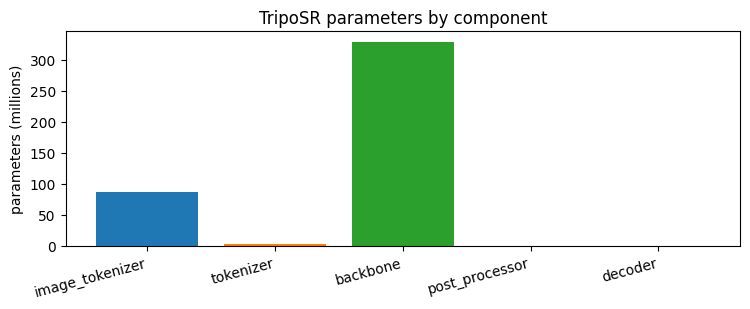

total: 419M parameters


In [4]:
# Load the pretrained model and see where its parameters live.
import torch

from starx import model as smodel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("loading pretrained TripoSR (first run downloads ~1.7 GB)...")
tsr_model = smodel.load_pretrained_tsr(TRIPOSR_DIR, device=device)

table = smodel.param_count_table(tsr_model)
components = {k: v["total"] / 1e6 for k, v in table.items() if k != "ALL"}
fig, ax = plt.subplots(figsize=(7.6, 3.2))
ax.bar(
    range(len(components)),
    list(components.values()),
    color=plt.get_cmap("tab10").colors[: len(components)],
    tick_label=list(components.keys()),
)
ax.set_ylabel("parameters (millions)")
ax.set_title("TripoSR parameters by component")
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
plt.show()
print(f"total: {table['ALL']['total'] / 1e6:.0f}M parameters")

/content/TripoSR/tsr/utils.py:376: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  right = F.normalize(torch.cross(lookat, up), dim=-1)


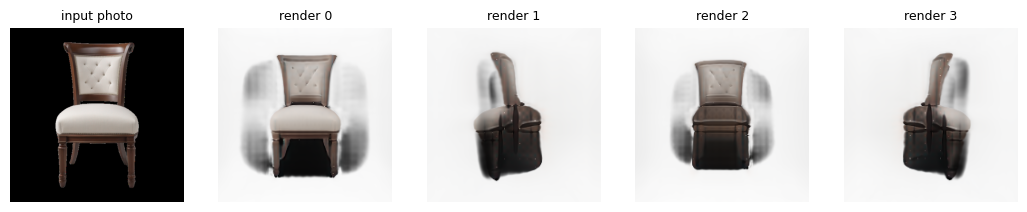

photo token tensor: (1, 768, 1025)


In [5]:
# Prove the environment before cutting: the intact RGB model on one of
# TripoSR's own example photos, plus its token statistics for later
# comparison against sketch tokens.
example_path = Path(TRIPOSR_DIR) / "examples" / "chair.png"
example_image = Image.open(example_path).convert("RGB")
with torch.no_grad():
    example_codes = tsr_model([example_image], device=device)
    tsr_model.renderer.set_chunk_size(cfg.eval_chunk)
    example_views = tsr_model.render(
        example_codes, n_views=4, height=192, width=192, return_type="np"
    )[0]

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
axes[0].imshow(example_image)
axes[0].set_title("input photo", fontsize=9)
for i in range(4):
    axes[i + 1].imshow(example_views[i])
    axes[i + 1].set_title(f"render {i}", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.show()

with torch.no_grad():
    # the preprocessor already returns a batched (1, H, W, C) tensor
    processed = tsr_model.image_processor(example_image, 512).to(device)
    rgb_tokens = tsr_model.image_tokenizer(processed.permute(0, 3, 1, 2))
rgb_token_norms = rgb_tokens.norm(dim=1).flatten().cpu().numpy()
print("photo token tensor:", tuple(rgb_tokens.shape))

## Why surgery

The pretrained model expects one photograph: three channels of RGB. StarX feeds it a stack of sketch channels - the i-th channel is the i-th sketch in the design's timeline, and unused slots hold plain background gray.

Two things must change for that to work:

1. the patch embedding needs one input slot per sketch channel instead of three color slots, initialized so the network's behavior is preserved (a blank gray slot should contribute exactly what gray background contributed in pretraining - "no sketch here" already means something to the model);
2. the input normalization buffers need one entry per slot.

Everything downstream - the triplane tokens, the backbone, the renderer - is untouched by the surgery itself; LoRA adapters then give the early encoder and the backbone just enough freedom to adapt.

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))


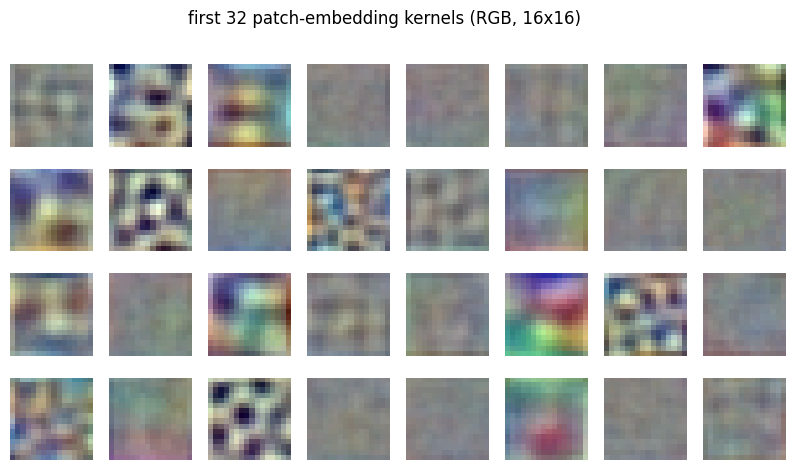

In [6]:
# The organ being operated on: the patch embedding that turns 16x16 pixel
# patches into tokens. Its kernels are what "seeing" means to this model.
projection = tsr_model.image_tokenizer.model.embeddings.patch_embeddings.projection
print(projection)

kernels = projection.weight.detach().cpu()[:32]
lo, hi = kernels.min(), kernels.max()
fig, axes = plt.subplots(4, 8, figsize=(10, 5.2))
for ax, kernel in zip(axes.ravel(), kernels):
    ax.imshow(((kernel - lo) / (hi - lo)).permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle("first 32 patch-embedding kernels (RGB, 16x16)")
plt.show()

In [7]:
# Surgery step 1: replace the 3-channel patch embedding with a 6-channel
# one. Every new slot gets the RGB-mean kernel scaled by 3/6, so a uniform
# input produces exactly the pretrained activations - verified numerically
# in float64 on CPU (GPU fp32 convs use TF32, whose ~1e-3 rounding would
# drown a strict equality check).
old_projection = projection
mean_kernel = old_projection.weight.mean(dim=1, keepdim=True)
new_projection = torch.nn.Conv2d(
    cfg.max_sketch_channels, old_projection.out_channels,
    kernel_size=old_projection.kernel_size, stride=old_projection.stride,
)
with torch.no_grad():
    new_projection.weight.copy_(
        mean_kernel.repeat(1, cfg.max_sketch_channels, 1, 1)
        * (3 / cfg.max_sketch_channels)
    )
    new_projection.bias.copy_(old_projection.bias)
new_projection = new_projection.to(device)

vit = tsr_model.image_tokenizer.model
vit.embeddings.patch_embeddings.projection = new_projection
vit.embeddings.patch_embeddings.num_channels = cfg.max_sketch_channels
vit.config.num_channels = cfg.max_sketch_channels

with torch.no_grad():
    gray_rgb = torch.full((1, 3, 64, 64), 0.5, dtype=torch.float64)
    gray_six = torch.full(
        (1, cfg.max_sketch_channels, 64, 64), 0.5, dtype=torch.float64
    )
    out_old = torch.nn.functional.conv2d(
        gray_rgb,
        old_projection.weight.detach().double().cpu(),
        old_projection.bias.detach().double().cpu(),
        stride=old_projection.stride,
    )
    out_new = torch.nn.functional.conv2d(
        gray_six,
        new_projection.weight.detach().double().cpu(),
        new_projection.bias.detach().double().cpu(),
        stride=new_projection.stride,
    )
    diff = (out_new - out_old).abs().max().item()
print(f"new conv: {new_projection}")
print(f"max activation difference on uniform gray (float64): {diff:.2e}")
assert diff < 1e-4, "inflation must preserve the uniform-input response"

new conv: Conv2d(6, 768, kernel_size=(16, 16), stride=(16, 16))
max activation difference on uniform gray (float64): 1.61e-07


In [8]:
# Surgery step 2: the tokenizer's normalization buffers currently hold
# per-RGB-channel statistics - extend them to one value per sketch slot,
# chosen so mid-gray normalizes near its pretraining value.
tokenizer = tsr_model.image_tokenizer
print("before:", tuple(tokenizer.image_mean.shape),
      [round(v, 3) for v in tokenizer.image_mean.flatten().tolist()])
reference = tokenizer.image_mean
tokenizer.image_mean = torch.full(
    (1, 1, cfg.max_sketch_channels, 1, 1), CHANNEL_MEAN,
    device=reference.device, dtype=reference.dtype,
)
tokenizer.image_std = torch.full(
    (1, 1, cfg.max_sketch_channels, 1, 1), CHANNEL_STD,
    device=reference.device, dtype=reference.dtype,
)
print("after: ", tuple(tokenizer.image_mean.shape),
      [round(v, 3) for v in tokenizer.image_mean.flatten().tolist()[:3]], "...")

before: (1, 1, 3, 1, 1) [0.485, 0.456, 0.406]
after:  (1, 1, 6, 1, 1) [0.449, 0.449, 0.449] ...


sketch token tensor: (1, 768, 1025)


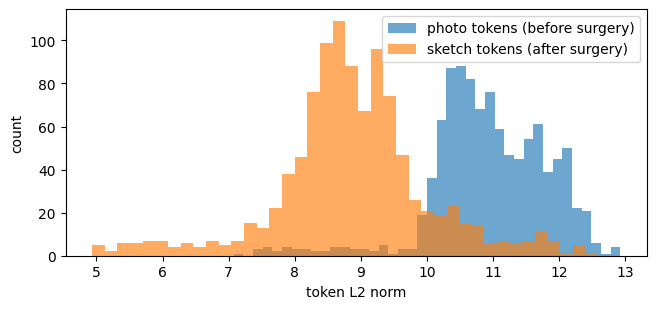

In [9]:
# Feed a real sketch stack through the surgered tokenizer and compare its
# token statistics against the photo tokens captured before surgery.
fixture = fusion.load_design(
    Path(REPO_DIR) / "tests" / "fixtures" / "20203_7e31e92a_0000.json"
)
stack, stack_meta = rasterize.rasterize_design(fixture, cfg)
sketch_tensor = rasterize.stack_to_tensor(stack)[None].to(device)
with torch.no_grad():
    sketch_tokens = tsr_model.image_tokenizer(sketch_tensor)
print("sketch token tensor:", tuple(sketch_tokens.shape))

sketch_norms = sketch_tokens.norm(dim=1).flatten().cpu().numpy()
colors = plt.get_cmap("tab10").colors
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(rgb_token_norms, bins=40, alpha=0.65, color=colors[0],
        label="photo tokens (before surgery)")
ax.hist(sketch_norms, bins=40, alpha=0.65, color=colors[1],
        label="sketch tokens (after surgery)")
ax.set_xlabel("token L2 norm")
ax.set_ylabel("count")
ax.legend()
plt.show()

## LoRA in one paragraph

Fine-tuning all 400+ million parameters would be slow, memory-hungry, and would risk destroying what pretraining learned. LoRA (low-rank adaptation) freezes every original weight and adds a small bypass to selected layers: two thin matrices whose product is a low-rank update, trained in place of the full weight. The model keeps its pretrained knowledge; the adapters learn the adjustment.

Where to put the adapters follows from what changed: the **early DINO layers** are the first to see the new input statistics (line drawings instead of photographs), and the **backbone's attention** is what carries sketch information into the triplane - both its self-attention and its cross-attention read the image tokens' new content. Everything else stays frozen.

In [10]:
# Verify the actual module names before injecting anything - LoRA targets
# are matched by name, and a typo would silently inject nothing.
dino_linears = [
    name
    for name, module in tsr_model.image_tokenizer.model.named_modules()
    if isinstance(module, torch.nn.Linear)
    and name.split(".")[-1] in ("query", "key", "value")
]
print(f"DINO attention Linears: {len(dino_linears)} total; early-layer targets:")
for name in dino_linears:
    layer = int(name.split("encoder.layer.")[1].split(".")[0])
    if layer in cfg.dino_layers:
        print("  ", name)

backbone_linears = [
    name
    for name, module in tsr_model.backbone.named_modules()
    if isinstance(module, torch.nn.Linear)
    and (name.endswith(("to_q", "to_k", "to_v")) or name.endswith("to_out.0"))
]
print(f"backbone attention Linears: {len(backbone_linears)}; first few:")
for name in backbone_linears[:6]:
    print("  ", name)

DINO attention Linears: 36 total; early-layer targets:
   encoder.layer.0.attention.attention.query
   encoder.layer.0.attention.attention.key
   encoder.layer.0.attention.attention.value
   encoder.layer.1.attention.attention.query
   encoder.layer.1.attention.attention.key
   encoder.layer.1.attention.attention.value
   encoder.layer.2.attention.attention.query
   encoder.layer.2.attention.attention.key
   encoder.layer.2.attention.attention.value
   encoder.layer.3.attention.attention.query
   encoder.layer.3.attention.attention.key
   encoder.layer.3.attention.attention.value
backbone attention Linears: 128; first few:
   transformer_blocks.0.attn1.to_q
   transformer_blocks.0.attn1.to_k
   transformer_blocks.0.attn1.to_v
   transformer_blocks.0.attn1.to_out.0
   transformer_blocks.0.attn2.to_q
   transformer_blocks.0.attn2.to_k


In [11]:
# Inject the adapters: one config for the early DINO layers, one for the
# backbone (its attention Linears use different names, so two injections).
# Expected counts: DINO = len(dino_layers) x 3 (query/key/value);
# backbone = 16 blocks x 2 attentions x 4 projections.
from peft import LoraConfig, inject_adapter_in_model

dino_config = LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    target_modules=["query", "key", "value"],
    layers_to_transform=list(cfg.dino_layers),
    layers_pattern="layer",
    bias="none",
)
backbone_config = LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    bias="none",
)
inject_adapter_in_model(dino_config, tsr_model.image_tokenizer.model, adapter_name="default")
inject_adapter_in_model(backbone_config, tsr_model.backbone, adapter_name="default")


def count_lora(module):
    return sum(1 for name, _ in module.named_modules() if name.endswith("lora_A"))


print("LoRA modules in DINO:    ", count_lora(tsr_model.image_tokenizer.model))
print("LoRA modules in backbone:", count_lora(tsr_model.backbone))

LoRA modules in DINO:     12
LoRA modules in backbone: 128


In [12]:
# Freeze everything, then unfreeze exactly what should learn: LoRA
# adapters, the new patch embedding, and (optionally) the triplane tokens.
for p in tsr_model.parameters():
    p.requires_grad_(False)
for name, p in tsr_model.named_parameters():
    if "lora_" in name:
        p.requires_grad_(True)
for p in tsr_model.image_tokenizer.model.embeddings.patch_embeddings.projection.parameters():
    p.requires_grad_(True)
if cfg.train_triplane_embed:
    tsr_model.tokenizer.embeddings.requires_grad_(True)

table = smodel.param_count_table(tsr_model)
table_df = pd.DataFrame(table).T
table_df["trainable %"] = (100 * table_df["trainable"] / table_df["total"]).round(2)
display(table_df)
totals = table["ALL"]
print(
    f"trainable: {totals['trainable']:,} of {totals['total']:,} "
    f"({100 * totals['trainable'] / totals['total']:.2f}%)"
)

,total,trainable,trainable %
image_tokenizer,87273984,1475328,1.69
tokenizer,3145728,0,0.00
backbone,333598720,4063232,1.22
post_processor,163880,0,0.00
decoder,41284,0,0.00
ALL,424223596,5538560,1.31


trainable: 5,538,560 of 424,223,596 (1.31%)


scene code: (1, 3, 40, 64, 64)


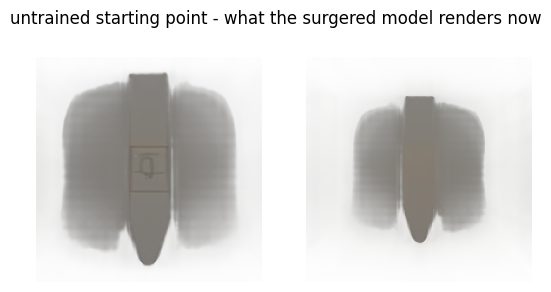

In [13]:
# The full forward pass, written as the four explicit stages training will
# use (TSR.forward assumes RGB photo preprocessing, so we compose by hand):
# sketch stack -> image tokens -> triplane tokens -> backbone -> scene code.
with torch.no_grad():
    image_tokens = tsr_model.image_tokenizer(sketch_tensor)  # (1, 768, Nt)
    image_tokens = image_tokens.permute(0, 2, 1)             # (1, Nt, 768)
    tokens = tsr_model.tokenizer(1)                          # (1, 1024, 3072)
    tokens = tsr_model.backbone(tokens, encoder_hidden_states=image_tokens)
    scene_code = tsr_model.post_processor(tsr_model.tokenizer.detokenize(tokens))
print("scene code:", tuple(scene_code.shape))

tsr_model.renderer.set_chunk_size(cfg.eval_chunk)
untrained_views = tsr_model.render(
    scene_code, n_views=2, height=192, width=192, return_type="np"
)[0]
fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.3))
for ax, view in zip(axes, untrained_views):
    ax.imshow(view)
    ax.axis("off")
fig.suptitle("untrained starting point - what the surgered model renders now")
plt.show()

In [14]:
# Probe: an all-blank stack (a design with zero sketches) should look to
# the network like the plain gray background it saw in pretraining -
# meaningfully different from a stack with real strokes.
blank = torch.full(
    (1, cfg.max_sketch_channels, cfg.sketch_size, cfg.sketch_size),
    cfg.bg_value / 255.0,
    device=device,
)
with torch.no_grad():
    blank_tokens = tsr_model.image_tokenizer(blank)
print(f"blank-stack token norm mean:  {float(blank_tokens.norm(dim=1).mean()):.2f}")
print(f"sketch-stack token norm mean: {float(sketch_tokens.norm(dim=1).mean()):.2f}")

blank-stack token norm mean:  9.06
sketch-stack token norm mean: 8.87


In [15]:
# Cross-check: the package builder must produce exactly the model we just
# built by hand - same tensors, same shapes, same trainable set. Notebooks
# 05-07 rebuild the architecture through the package, so this assert is
# what makes their checkpoints compatible with this walkthrough.
fresh_model, info = smodel.build_starx_model(cfg, TRIPOSR_DIR, device="cpu")

hand_shapes = {k: tuple(v.shape) for k, v in tsr_model.state_dict().items()}
pkg_shapes = {k: tuple(v.shape) for k, v in fresh_model.state_dict().items()}
assert hand_shapes == pkg_shapes, "state dict mismatch vs package builder"

hand_trainable = {n for n, p in tsr_model.named_parameters() if p.requires_grad}
pkg_trainable = {n for n, p in fresh_model.named_parameters() if p.requires_grad}
assert hand_trainable == pkg_trainable, "trainable set mismatch vs package builder"

print(f"package builder matches: {len(pkg_shapes)} tensors, "
      f"{len(pkg_trainable)} trainable")
print("lora modules injected:", info["lora_counts"])
del fresh_model

package builder matches: 829 tensors, 282 trainable
lora modules injected: {'dino_lora_modules': 12, 'backbone_lora_modules': 128}


## What training does with this

The surgered model now accepts a sketch stack and produces a triplane scene code, but nothing has taught the new pieces what sketches mean: the renders above are the "before" picture. Notebook 05 optimizes the small trainable set - the inflated patch embedding and the LoRA adapters - with a rendering loss against the ground-truth views built in notebook 03.